In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [2]:
DATASET_PATH = r"C:\Users\user\Downloads\archive (4)\WA_Fn-UseC_-Telco-Customer-Churn.csv"

if not os.path.isfile(DATASET_PATH):
    print("❌ Dataset not found.")
    print("Check the path above and run this cell again.")
else:
    df = pd.read_csv(DATASET_PATH)
    print("✅ Dataset loaded successfully!")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])

✅ Dataset loaded successfully!
Rows: 7043
Columns: 21


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0])

if missing.sum() == 0:
    print("✅ No missing values detected.")

Series([], dtype: int64)

✅ No missing values detected.


In [7]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

if duplicates == 0:
    print("✅ No duplicate rows detected.")

Duplicate rows: 0
✅ No duplicate rows detected.


In [8]:
data = df.copy()

data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"], errors="coerce"
)

data = data.dropna(subset=["Churn"]).copy()
data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].median())
data = data.drop_duplicates().copy()

data["Churn_Flag"] = data["Churn"].map({"Yes": 1, "No": 0})

print("✅ Cleaning completed.")
print("Rows after cleaning:", len(data))
print("Remaining missing cells:", int(data.isnull().sum().sum()))

✅ Cleaning completed.
Rows after cleaning: 7043
Remaining missing cells: 0


In [9]:
display(data.head())

print("\nChurn distribution:")
display(data["Churn"].value_counts())

print("\nRemaining missing values:")
display(data.isnull().sum()[data.isnull().sum() > 0])

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1



Churn distribution:


Churn
No     5174
Yes    1869
Name: count, dtype: int64


Remaining missing values:


Series([], dtype: int64)

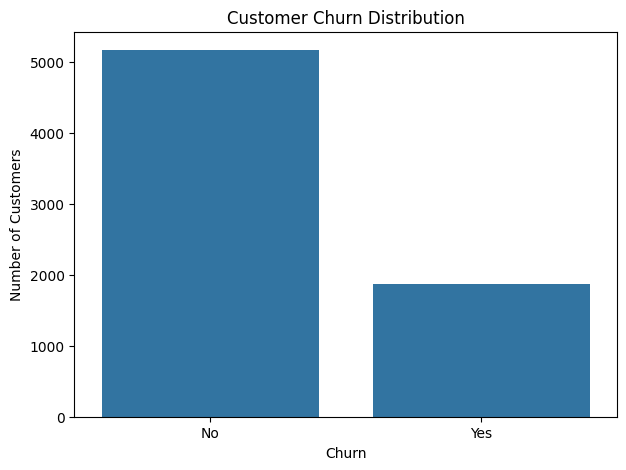

In [10]:
plt.figure(figsize=(7,5))
sns.countplot(data=data, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [11]:
churn_rate = data["Churn_Flag"].mean() * 100
print(f"Overall observed churn rate: {churn_rate:.2f}%")

Overall observed churn rate: 26.54%


,Churn Rate (%)
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


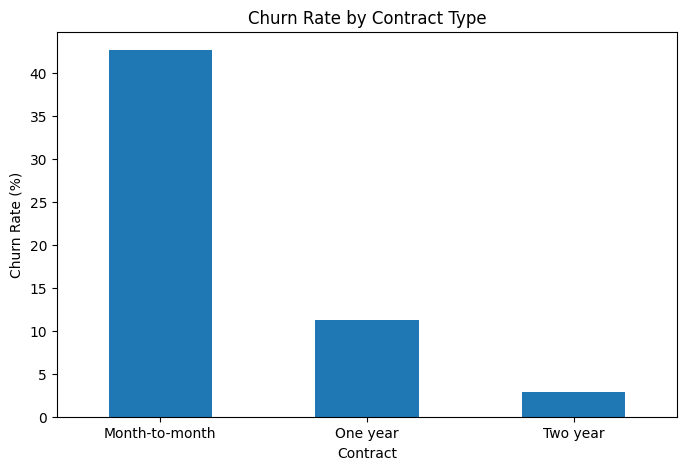

In [12]:
contract_churn = (
    data.groupby("Contract")["Churn_Flag"]
    .mean().mul(100).sort_values(ascending=False)
)

display(contract_churn.to_frame("Churn Rate (%)"))

plt.figure(figsize=(8,5))
contract_churn.plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

,Churn Rate (%)
Tenure_Group,
0-12 Months,47.438243
13-24 Months,28.710938
25-48 Months,20.388959
49-72 Months,9.513176


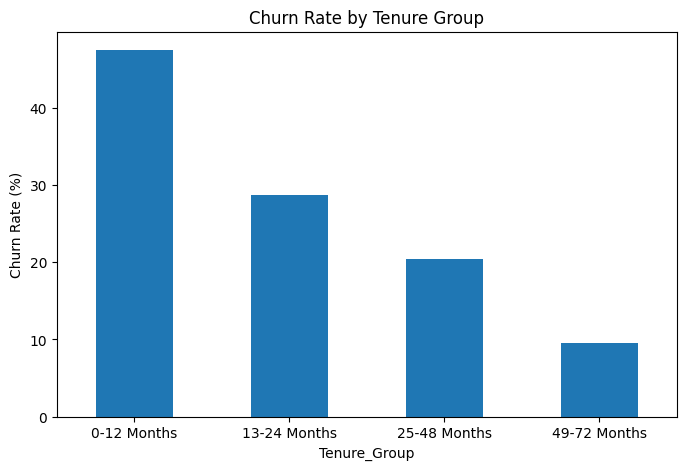

In [13]:
data["Tenure_Group"] = pd.cut(
    data["tenure"],
    bins=[-1,12,24,48,72],
    labels=["0-12 Months","13-24 Months","25-48 Months","49-72 Months"]
)

tenure_churn = (
    data.groupby("Tenure_Group", observed=False)["Churn_Flag"]
    .mean().mul(100)
)

display(tenure_churn.to_frame("Churn Rate (%)"))

plt.figure(figsize=(8,5))
tenure_churn.plot(kind="bar")
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

,Churn Rate (%)
InternetService,
Fiber optic,41.892765
DSL,18.959108
No,7.404980


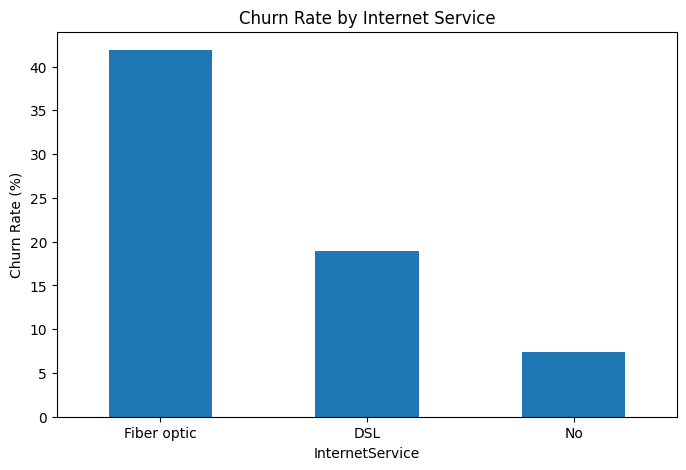

In [14]:
internet_churn = (
    data.groupby("InternetService")["Churn_Flag"]
    .mean().mul(100).sort_values(ascending=False)
)

display(internet_churn.to_frame("Churn Rate (%)"))

plt.figure(figsize=(8,5))
internet_churn.plot(kind="bar")
plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

,Churn Rate (%)
PaymentMethod,
Electronic check,45.285412
Mailed check,19.106700
Bank transfer (automatic),16.709845
Credit card (automatic),15.243101


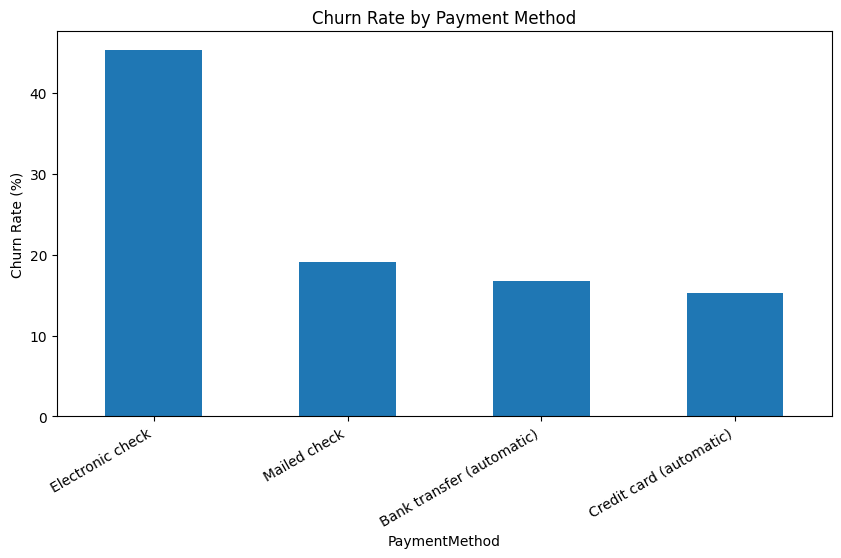

In [15]:
payment_churn = (
    data.groupby("PaymentMethod")["Churn_Flag"]
    .mean().mul(100).sort_values(ascending=False)
)

display(payment_churn.to_frame("Churn Rate (%)"))

plt.figure(figsize=(10,5))
payment_churn.plot(kind="bar")
plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

In [16]:
total_customers = len(data)
churned_customers = int(data["Churn_Flag"].sum())
overall_churn_rate = data["Churn_Flag"].mean() * 100
avg_monthly_charges = data["MonthlyCharges"].mean()
total_monthly_charges = data["MonthlyCharges"].sum()

kpis = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Churned Customers",
        "Churn Rate (%)",
        "Average Monthly Charges",
        "Total Monthly Charges"
    ],
    "Value": [
        total_customers,
        churned_customers,
        round(overall_churn_rate, 2),
        round(avg_monthly_charges, 2),
        round(total_monthly_charges, 2)
    ]
})

display(kpis)

,KPI,Value
0,Total Customers,7043.00
1,Churned Customers,1869.00
2,Churn Rate (%),26.54
3,Average Monthly Charges,64.76
4,Total Monthly Charges,456116.60


In [17]:
model_data = data.copy()

X = model_data.drop(
    columns=["Churn", "Churn_Flag", "customerID", "Tenure_Group"]
)
y = model_data["Churn_Flag"]

numeric_features = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object","category","bool"]
).columns.tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 5634
Testing rows: 1409


In [19]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline.fit(X_train, y_train)

print("✅ Model training completed successfully.")

✅ Model training completed successfully.


In [20]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print("✅ Predictions generated.")

✅ Predictions generated.


In [21]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

metrics = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1 Score","ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

metrics["Score"] = metrics["Score"].round(4)
display(metrics)

,Metric,Score
0,Accuracy,0.7381
1,Precision,0.5043
2,Recall,0.7834
3,F1 Score,0.6136
4,ROC-AUC,0.8413


In [22]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Churned","Churned"],
    zero_division=0
))

              precision    recall  f1-score   support

 Not Churned       0.90      0.72      0.80      1035
     Churned       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



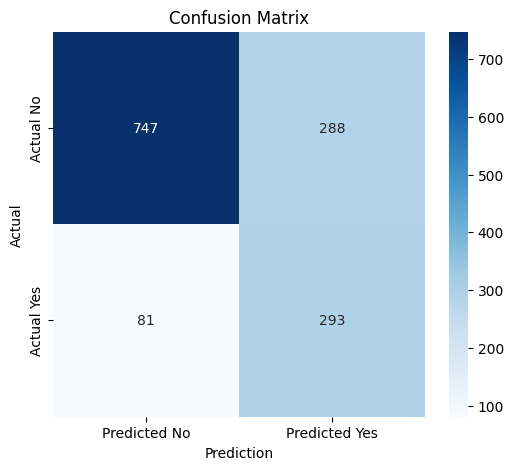

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No","Predicted Yes"],
    yticklabels=["Actual No","Actual Yes"]
)
plt.title("Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

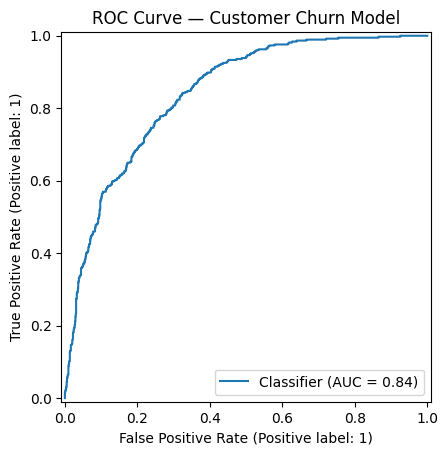

In [24]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve — Customer Churn Model")
plt.show()

In [25]:
risk_data = data.copy()

risk_data["Churn_Probability"] = pipeline.predict_proba(X)[:,1]

risk_data["Risk_Tier"] = pd.cut(
    risk_data["Churn_Probability"],
    bins=[-0.01, 0.35, 0.65, 1.0],
    labels=["Low","Medium","High"]
)

display(
    risk_data[
        [
            "customerID","tenure","Contract",
            "MonthlyCharges","Churn_Probability","Risk_Tier"
        ]
    ].head(10)
)

,customerID,tenure,Contract,MonthlyCharges,Churn_Probability,Risk_Tier
0,7590-VHVEG,1,Month-to-month,29.85,0.802138,High
1,5575-GNVDE,34,One year,56.95,0.118952,Low
2,3668-QPYBK,2,Month-to-month,53.85,0.531901,Medium
3,7795-CFOCW,45,One year,42.30,0.081651,Low
4,9237-HQITU,2,Month-to-month,70.70,0.854034,High
5,9305-CDSKC,8,Month-to-month,99.65,0.909209,High
6,1452-KIOVK,22,Month-to-month,89.10,0.720264,High
7,6713-OKOMC,10,Month-to-month,29.75,0.522655,Medium
8,7892-POOKP,28,Month-to-month,104.80,0.816855,High
9,6388-TABGU,62,One year,56.15,0.033943,Low


,Customers
Risk_Tier,
Low,3254
Medium,1703
High,2086


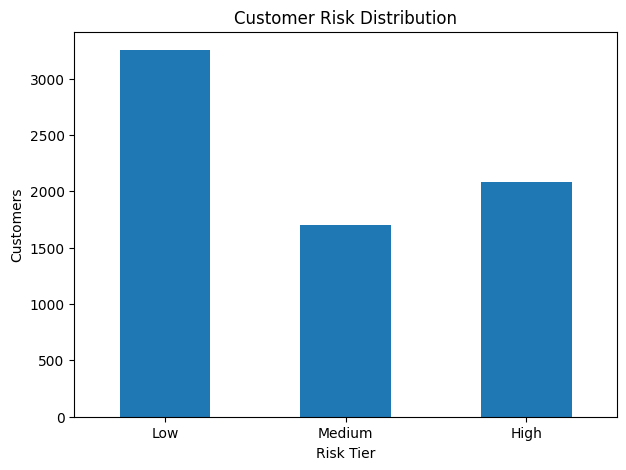

In [26]:
risk_distribution = (
    risk_data["Risk_Tier"]
    .value_counts()
    .reindex(["Low","Medium","High"])
)

display(risk_distribution.to_frame("Customers"))

plt.figure(figsize=(7,5))
risk_distribution.plot(kind="bar")
plt.title("Customer Risk Distribution")
plt.xlabel("Risk Tier")
plt.ylabel("Customers")
plt.xticks(rotation=0)
plt.show()

In [27]:
high_risk = risk_data[risk_data["Risk_Tier"] == "High"].copy()

high_risk_customers = len(high_risk)
monthly_revenue_at_risk = high_risk["MonthlyCharges"].sum()

print("High-risk customers:", high_risk_customers)
print(
    f"Monthly charges associated with high-risk customers: "
    f"${monthly_revenue_at_risk:,.2f}"
)

High-risk customers: 2086
Monthly charges associated with high-risk customers: $164,795.80


In [28]:
top_risk_customers = (
    risk_data
    .sort_values(
        ["Churn_Probability","MonthlyCharges"],
        ascending=[False,False]
    )
    [[
        "customerID","tenure","Contract",
        "InternetService","PaymentMethod",
        "MonthlyCharges","Churn_Probability","Risk_Tier"
    ]]
    .head(20)
)

display(top_risk_customers)

,customerID,tenure,Contract,InternetService,PaymentMethod,MonthlyCharges,Churn_Probability,Risk_Tier
1976,9497-QCMMS,1,Month-to-month,Fiber optic,Electronic check,93.55,0.939111,High
4800,9300-AGZNL,1,Month-to-month,Fiber optic,Electronic check,94.00,0.938547,High
3380,5178-LMXOP,1,Month-to-month,Fiber optic,Electronic check,95.10,0.938071,High
3749,4424-TKOPW,2,Month-to-month,Fiber optic,Electronic check,93.85,0.937278,High
6368,2720-WGKHP,2,Month-to-month,Fiber optic,Electronic check,94.00,0.936905,High
5989,5567-WSELE,3,Month-to-month,Fiber optic,Electronic check,94.60,0.935500,High
1410,7024-OHCCK,2,Month-to-month,Fiber optic,Electronic check,93.85,0.935028,High
3159,5150-ITWWB,3,Month-to-month,Fiber optic,Electronic check,94.85,0.934893,High
2208,7216-EWTRS,1,Month-to-month,Fiber optic,Electronic check,100.80,0.932437,High
997,1374-DMZUI,4,Month-to-month,Fiber optic,Electronic check,94.30,0.931894,High


In [29]:
highest_contract = contract_churn.idxmax()
highest_contract_rate = contract_churn.max()

highest_internet = internet_churn.idxmax()
highest_internet_rate = internet_churn.max()

highest_payment = payment_churn.idxmax()
highest_payment_rate = payment_churn.max()

print("BUSINESS INSIGHT SUMMARY")
print("="*60)
print(f"1. Overall observed churn rate: {overall_churn_rate:.2f}%")
print(
    f"2. Contract segment with highest observed churn rate: "
    f"{highest_contract} ({highest_contract_rate:.2f}%)"
)
print(
    f"3. Internet-service segment with highest observed churn rate: "
    f"{highest_internet} ({highest_internet_rate:.2f}%)"
)
print(
    f"4. Payment-method segment with highest observed churn rate: "
    f"{highest_payment} ({highest_payment_rate:.2f}%)"
)
print(
    f"5. Customers classified as high risk: {high_risk_customers}"
)
print(
    f"6. Monthly charges associated with high-risk customers: "
    f"${monthly_revenue_at_risk:,.2f}"
)

BUSINESS INSIGHT SUMMARY
1. Overall observed churn rate: 26.54%
2. Contract segment with highest observed churn rate: Month-to-month (42.71%)
3. Internet-service segment with highest observed churn rate: Fiber optic (41.89%)
4. Payment-method segment with highest observed churn rate: Electronic check (45.29%)
5. Customers classified as high risk: 2086
6. Monthly charges associated with high-risk customers: $164,795.80


In [30]:
checks = {
    "Dataset loaded": "df" in globals(),
    "Clean dataset created": "data" in globals(),
    "Model trained": "pipeline" in globals(),
    "Predictions generated": "y_pred" in globals(),
    "Risk scores generated": "risk_data" in globals(),
    "Metrics calculated": "metrics" in globals(),
    "High-risk analysis completed": "high_risk" in globals()
}

print("FINAL PROJECT VERIFICATION")
print("="*60)

for name, result in checks.items():
    print(("✅ " if result else "❌ ") + name)

if all(checks.values()):
    print("\n🎉 PROJECT PIPELINE COMPLETED SUCCESSFULLY!")
else:
    print("\n⚠️ Some steps are incomplete. Check the cells above.")

FINAL PROJECT VERIFICATION
✅ Dataset loaded
✅ Clean dataset created
✅ Model trained
✅ Predictions generated
✅ Risk scores generated
✅ Metrics calculated
✅ High-risk analysis completed

🎉 PROJECT PIPELINE COMPLETED SUCCESSFULLY!
